Kalman testdata: 739 wedstrijden (['2024/2025', '2025/2026'])
  E0 (1).csv: 349 rijen (2025-08-15 → 2026-05-04)
  E0 (2).csv: 380 rijen (2024-08-16 → 2025-05-25)

Totaal odds: 729 wedstrijden
B365H gevuld: 729

Kalman kansen berekend voor 739 wedstrijden

Gekoppeld met Bet365 odds: 729 wedstrijden
Periode: 2024-08-16 → 2026-05-04

Cold-start filter (eerste 5 wedstrijden per team):
  Uitgesloten : 128 wedstrijden
  Overgebleven: 601 wedstrijden

Gemiddelde Bet365 marge: 5.57%

=== OVERZICHT METRICS ===
Model                  Accuracy      RPS    Brier
--------------------------------------------------
Kalman EKF                0.537   0.2080   0.2026
Bet365                    0.519   0.2058   0.2005

=== RPS PER SEIZOEN ===
Model                   2024/25    2025/26
------------------------------------------
Kalman EKF               0.2031     0.2123
Bet365                   0.2036     0.2077

=== WILCOXON SIGNIFICANTIETESTS ===

  RPS:
  Kalman vs Bet365: stat=86709.0, p=0.3796 | Bet36

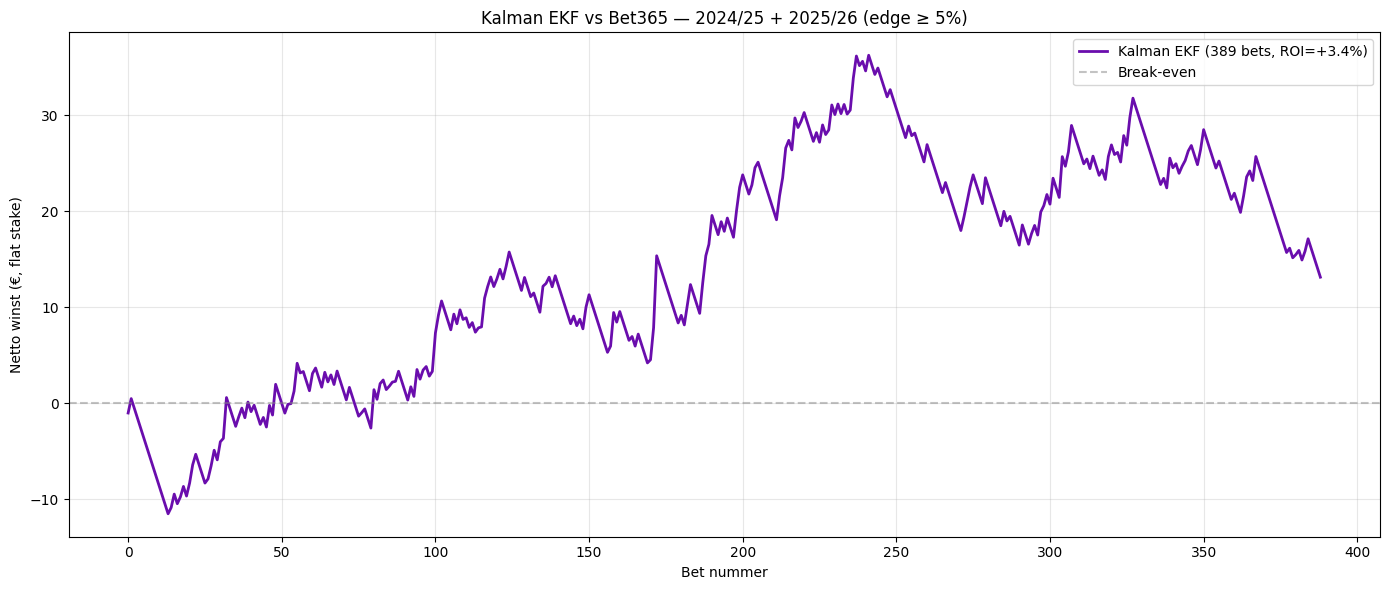


Klaar.


In [1]:
"""
Kalman Betting Simulatie — Bet365 (2024/25 + 2025/26)
=========================================================================
Input:
  - kalman_expected_goals.csv
  - odds raw/E0*.csv  (2024/25 + 2025/26)

Benchmarks:
  - Bet365 implied probabilities (marge-gecorrigeerd)

Cold-start filter: eerste 5 wedstrijden per team uitgesloten
"""

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson, wilcoxon
from sklearn.metrics import accuracy_score, brier_score_loss

warnings.filterwarnings('ignore')

BASE_DIR = r"C:\Users\semwi\FPL-Core-Insights_Thesis\data"
os.chdir(BASE_DIR)

TEST_SEASONS = {"2024/2025", "2025/2026"}

# ══════════════════════════════════════════════════════════════════════════════
# STAP 1 — Data laden
# ══════════════════════════════════════════════════════════════════════════════
ODDS_TEAM_MAP = {
    "Man United":    "Manchester United",
    "Man City":      "Manchester City",
    "Tottenham":     "Tottenham Hotspur",
    "Newcastle":     "Newcastle United",
    "Brighton":      "Brighton & Hove Albion",
    "West Ham":      "West Ham United",
    "Leicester":     "Leicester City",
    "Ipswich":       "Ipswich Town",
    "Luton":         "Luton Town",
    "Wolves":        "Wolverhampton Wanderers",
    "Wolverhampton": "Wolverhampton Wanderers",
    "Nott'm Forest": "Nottingham Forest",
    "Leeds":         "Leeds United",
    "West Brom":     "West Bromwich Albion",
}

KALMAN_TEAM_MAP = {
    "Wolverhampton":           "Wolverhampton Wanderers",
    "Wolverhampton Wanderers": "Wolverhampton Wanderers",
}

kalman = pd.read_csv(r"kalman_expected_goals.csv")
kalman['date'] = pd.to_datetime(kalman['date'])
kalman = kalman[kalman['season'].isin(TEST_SEASONS)].copy()
print(f"Kalman testdata: {len(kalman)} wedstrijden ({sorted(TEST_SEASONS)})")

odds_dfs = []
for path in sorted(glob.glob(os.path.join(BASE_DIR, r"odds raw\E0*.csv"))):
    df = pd.read_csv(path, encoding='latin-1')
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df = df[df['Date'] >= '2024-08-01']
    if len(df) > 0:
        odds_dfs.append(df)
        print(f"  {os.path.basename(path)}: {len(df)} rijen "
              f"({df['Date'].min().date()} → {df['Date'].max().date()})")

odds = pd.concat(odds_dfs, ignore_index=True)
odds['HomeTeam'] = odds['HomeTeam'].replace(ODDS_TEAM_MAP)
odds['AwayTeam'] = odds['AwayTeam'].replace(ODDS_TEAM_MAP)
odds['_date'] = odds['Date'].dt.date.astype(str)

print(f"\nTotaal odds: {len(odds)} wedstrijden")
print(f"B365H gevuld: {odds['B365H'].notna().sum()}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 2 — Kalman kansen berekenen
# ══════════════════════════════════════════════════════════════════════════════
SCALE_HOME = 1.3410
SCALE_AWAY = 1.3378
RHO        = -0.13
MAX_GOALS  = 12

def dixon_coles_tau(goals_h, goals_a, lambda_h, lambda_a, rho=RHO):
    if goals_h == 0 and goals_a == 0:   return 1 - lambda_h * lambda_a * rho
    elif goals_h == 1 and goals_a == 0: return 1 + lambda_a * rho
    elif goals_h == 0 and goals_a == 1: return 1 + lambda_h * rho
    elif goals_h == 1 and goals_a == 1: return 1 - rho
    return 1.0

def xg_to_probabilities(lambda_home, lambda_away, max_goals=MAX_GOALS, rho=RHO):
    lambda_home = max(lambda_home, 0.05) * SCALE_HOME
    lambda_away = max(lambda_away, 0.05) * SCALE_AWAY
    prob_home = prob_draw = prob_away = 0.0
    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = (poisson.pmf(i, lambda_home)
                 * poisson.pmf(j, lambda_away)
                 * dixon_coles_tau(i, j, lambda_home, lambda_away, rho))
            if i > j:    prob_home += p
            elif i == j: prob_draw += p
            else:        prob_away += p
    total = prob_home + prob_draw + prob_away
    return (prob_home / total, prob_draw / total, prob_away / total)

kalman_valid = kalman[kalman['kalman_xg_pred_home'].notna()].copy()
kalman_valid['home_team'] = kalman_valid['home_team'].replace(KALMAN_TEAM_MAP)
kalman_valid['away_team'] = kalman_valid['away_team'].replace(KALMAN_TEAM_MAP)

probs = kalman_valid.apply(
    lambda row: xg_to_probabilities(row['kalman_xg_pred_home'], row['kalman_xg_pred_away']), axis=1)
kalman_valid['kalman_prob_home'] = [p[0] for p in probs]
kalman_valid['kalman_prob_draw'] = [p[1] for p in probs]
kalman_valid['kalman_prob_away'] = [p[2] for p in probs]
kalman_valid['_date'] = kalman_valid['date'].dt.date.astype(str)

print(f"\nKalman kansen berekend voor {len(kalman_valid)} wedstrijden")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 3 — Mergen met Bet365 odds
# ══════════════════════════════════════════════════════════════════════════════
merged = kalman_valid.merge(
    odds[['_date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'B365H', 'B365D', 'B365A']],
    left_on=['_date', 'home_team', 'away_team'],
    right_on=['_date', 'HomeTeam', 'AwayTeam'],
    how='inner'
).drop(columns=['HomeTeam', 'AwayTeam', '_date'])

merged['home_goals'] = merged['FTHG'].astype(float)
merged['away_goals'] = merged['FTAG'].astype(float)
merged = merged[merged['home_goals'].notna() & merged['away_goals'].notna()].copy()
merged['result'] = merged.apply(
    lambda r: 'H' if r['home_goals'] > r['away_goals']
              else ('A' if r['home_goals'] < r['away_goals'] else 'D'), axis=1)
merged = merged[merged['B365H'].notna()].copy()
merged = merged.sort_values(['season', 'date']).reset_index(drop=True)

print(f"\nGekoppeld met Bet365 odds: {len(merged)} wedstrijden")
print(f"Periode: {merged['date'].min().date()} → {merged['date'].max().date()}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 4 — Cold-start filter
# ══════════════════════════════════════════════════════════════════════════════
COLD_START_MATCHES = 5

merged['home_match_nr'] = merged.groupby('home_team').cumcount() + 1
merged['away_match_nr'] = merged.groupby('away_team').cumcount() + 1
cold_mask = ((merged['home_match_nr'] <= COLD_START_MATCHES) |
             (merged['away_match_nr'] <= COLD_START_MATCHES))

merged = merged[~cold_mask].copy().reset_index(drop=True)
print(f"\nCold-start filter (eerste {COLD_START_MATCHES} wedstrijden per team):")
print(f"  Uitgesloten : {cold_mask.sum()} wedstrijden")
print(f"  Overgebleven: {len(merged)} wedstrijden")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 5 — Bet365 marge-correctie → 100%
# ══════════════════════════════════════════════════════════════════════════════
merged['b365_prob_home'] = 1 / merged['B365H']
merged['b365_prob_draw'] = 1 / merged['B365D']
merged['b365_prob_away'] = 1 / merged['B365A']

total = merged['b365_prob_home'] + merged['b365_prob_draw'] + merged['b365_prob_away']
print(f"\nGemiddelde Bet365 marge: {((total - 1) * 100).mean():.2f}%")

merged['b365_prob_home'] = (merged['b365_prob_home'] / total).clip(0, 1)
merged['b365_prob_draw'] = (merged['b365_prob_draw'] / total).clip(0, 1)
merged['b365_prob_away'] = (merged['b365_prob_away'] / total).clip(0, 1)

# ══════════════════════════════════════════════════════════════════════════════
# STAP 6 — Evaluatie metrics
# ══════════════════════════════════════════════════════════════════════════════
def rps_row(p_home, p_draw, p_away, result):
    cp1 = p_home
    cp2 = p_home + p_draw
    o1  = 1.0 if result == 'H' else 0.0
    o2  = 1.0 if result in ['H', 'D'] else 0.0
    return 0.5 * ((cp1 - o1)**2 + (cp2 - o2)**2)

def brier_per_match(df, ph, pd_, pa):
    b_h = (df[ph] - (df['result'] == 'H').astype(int)) ** 2
    b_d = (df[pd_] - (df['result'] == 'D').astype(int)) ** 2
    b_a = (df[pa] - (df['result'] == 'A').astype(int)) ** 2
    return (b_h + b_d + b_a) / 3

# RPS per wedstrijd
merged['rps_kalman'] = merged.apply(
    lambda r: rps_row(r['kalman_prob_home'], r['kalman_prob_draw'],
                      r['kalman_prob_away'], r['result']), axis=1)
merged['rps_b365'] = merged.apply(
    lambda r: rps_row(r['b365_prob_home'], r['b365_prob_draw'],
                      r['b365_prob_away'], r['result']), axis=1)

# Brier per wedstrijd
merged['brier_kalman'] = brier_per_match(merged, 'kalman_prob_home', 'kalman_prob_draw', 'kalman_prob_away')
merged['brier_b365']   = brier_per_match(merged, 'b365_prob_home',   'b365_prob_draw',   'b365_prob_away')

# Overzichtstabel
print("\n=== OVERZICHT METRICS ===")
print(f"{'Model':<20} {'Accuracy':>10} {'RPS':>8} {'Brier':>8}")
print("-" * 50)
for label, ph, pd_, pa, rps_col, brier_col in [
    ('Kalman EKF', 'kalman_prob_home', 'kalman_prob_draw', 'kalman_prob_away', 'rps_kalman', 'brier_kalman'),
    ('Bet365',     'b365_prob_home',   'b365_prob_draw',   'b365_prob_away',   'rps_b365',   'brier_b365'),
]:
    pred = merged[[ph, pd_, pa]].idxmax(axis=1).map({ph: 'H', pd_: 'D', pa: 'A'})
    acc   = accuracy_score(merged['result'], pred)
    rps   = merged[rps_col].mean()
    brier = merged[brier_col].mean()
    print(f"{label:<20} {acc:>10.3f} {rps:>8.4f} {brier:>8.4f}")

# Per seizoen
print("\n=== RPS PER SEIZOEN ===")
print(f"{'Model':<20} {'2024/25':>10} {'2025/26':>10}")
print("-" * 42)
for label, col in [('Kalman EKF', 'rps_kalman'), ('Bet365', 'rps_b365')]:
    r = {}
    for s in ['2024/2025', '2025/2026']:
        sub = merged[merged['season'] == s]
        r[s] = sub[col].mean() if len(sub) > 0 else float('nan')
    print(f"{label:<20} {r['2024/2025']:>10.4f} {r['2025/2026']:>10.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 7 — Wilcoxon significantietests
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== WILCOXON SIGNIFICANTIETESTS ===")
for metric, metric_label in [('rps', 'RPS'), ('brier', 'Brier')]:
    print(f"\n  {metric_label}:")
    col_k = f"{metric}_kalman"
    col_b = f"{metric}_b365"
    stat, p = wilcoxon(merged[col_k], merged[col_b])
    diff    = merged[col_k].mean() - merged[col_b].mean()
    richting = "Kalman beter" if diff < 0 else "Bet365 beter"
    sig      = "✓ significant (p < 0.05)" if p < 0.05 else "✗ niet significant"
    print(f"  Kalman vs Bet365: stat={stat:.1f}, p={p:.4f} | {richting} | {sig}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 8 — Betting simulatie
# ══════════════════════════════════════════════════════════════════════════════
EDGE = 0.05

def simuleer(df, edge_threshold=EDGE):
    bet_results = []
    bankroll = 0.0
    bets = 0

    for _, row in df.iterrows():
        edges = {
            'H': row['kalman_prob_home'] - row['b365_prob_home'],
            'D': row['kalman_prob_draw'] - row['b365_prob_draw'],
            'A': row['kalman_prob_away'] - row['b365_prob_away'],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= edge_threshold:
            bookie_odds = row['B365H' if best == 'H' else 'B365D' if best == 'D' else 'B365A']
            if pd.isna(bookie_odds) or bookie_odds <= 1:
                continue
            bets += 1
            profit = (bookie_odds - 1) if row['result'] == best else -1.0
            bankroll += profit
            bet_results.append({
                'match'     : f"{row['home_team']} vs {row['away_team']}",
                'date'      : str(row['date'].date()),
                'season'    : row['season'],
                'bet'       : best,
                'result'    : row['result'],
                'edge'      : round(edges[best], 3),
                'odds'      : round(bookie_odds, 2),
                'profit'    : round(profit, 2),
                'cumulative': round(bankroll, 2),
                'won'       : row['result'] == best,
            })

    results_df = pd.DataFrame(bet_results)
    roi     = bankroll / bets * 100 if bets > 0 else 0
    winrate = results_df['won'].mean() * 100 if len(results_df) > 0 else 0

    print(f"\n{'='*55}")
    print(f"  KALMAN vs BET365 (edge ≥ {edge_threshold*100:.0f}%)")
    print(f"{'='*55}")
    print(f"  Wedstrijden beschikbaar : {len(df)}")
    print(f"  Bets geplaatst          : {bets}")
    print(f"  Netto resultaat         : €{bankroll:.2f}")
    print(f"  ROI                     : {roi:+.1f}%")
    print(f"  Win rate                : {winrate:.1f}%")

    if len(results_df) > 0:
        print(f"\n  Per uitkomst:")
        for outcome in ['H', 'D', 'A']:
            sub = results_df[results_df['bet'] == outcome]
            if len(sub) > 0:
                label = {'H': 'Thuis', 'D': 'Gelijk', 'A': 'Uit'}[outcome]
                roi_o = sub['profit'].sum() / len(sub) * 100
                print(f"    {label:<8}: {len(sub):>4} bets, ROI={roi_o:+.1f}%")

    return results_df

res_b365 = simuleer(merged, EDGE)

# ROI per drempel
print("\n=== ROI BIJ VERSCHILLENDE DREMPELS ===")
print(f"{'Drempel':>8} | {'ROI':>8} | {'Bets':>6}")
print("-" * 30)
for drempel in [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    winst = bets = 0
    for _, row in merged.iterrows():
        edges = {
            'H': row['kalman_prob_home'] - row['b365_prob_home'],
            'D': row['kalman_prob_draw'] - row['b365_prob_draw'],
            'A': row['kalman_prob_away'] - row['b365_prob_away'],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= drempel:
            bo = row['B365H' if best == 'H' else 'B365D' if best == 'D' else 'B365A']
            if pd.isna(bo) or bo <= 1: continue
            bets  += 1
            winst += (bo - 1) if row['result'] == best else -1
    roi = winst / bets * 100 if bets > 0 else 0
    print(f"{drempel:>8.2f} | {roi:>+7.1f}% | {bets:>6}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 9 — Visualisatie
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

if len(res_b365) > 0:
    roi = res_b365['profit'].sum() / len(res_b365) * 100
    ax.plot(range(len(res_b365)), res_b365['cumulative'],
            linewidth=2, color='#6A0DAD',
            label=f'Kalman EKF ({len(res_b365)} bets, ROI={roi:+.1f}%)')

ax.axhline(0, color='#888888', linestyle='--', alpha=0.5, label='Break-even')
ax.set_title(f'Kalman EKF vs Bet365 — 2024/25 + 2025/26 (edge ≥ {EDGE*100:.0f}%)')
ax.set_xlabel('Bet nummer')
ax.set_ylabel('Netto winst (€, flat stake)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}\\kalman_vs_bet365.png", dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# STAP 10 — Opslaan
# ══════════════════════════════════════════════════════════════════════════════
if len(res_b365) > 0:
    res_b365.to_csv(f"{BASE_DIR}\\betting_results_b365.csv", index=False)
merged.to_csv(f"{BASE_DIR}\\evaluation_metrics_b365.csv", index=False)

print("\nKlaar.")